In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

from sklearn.preprocessing import LabelEncoder , StandardScaler
from sklearn.model_selection import train_test_split , GridSearchCV

from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectFromModel


from sklearn.ensemble import RandomForestClassifier



from sklearn.metrics import accuracy_score , classification_report , confusion_matrix 

from sklearn.decomposition import PCA 
from xgboost import XGBClassifier 
from sklearn.metrics import accuracy_score, recall_score, f1_score, confusion_matrix, classification_report

df = pd.read_csv('dataset/bank-full.csv')


In [22]:
df.replace("unknown", np.nan, inplace=True)

num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

df['y'] = df['y'].map({'yes': 1, 'no': 0})

categorical_cols = df.select_dtypes(include=['object']).columns
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
     df[col] = le.fit_transform(df[col])
    

X = df.drop('y', axis=1)
y = df['y']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

E:\temp\ipykernel_7424\1602024045.py:4: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns
E:\temp\ipykernel_7424\1602024045.py:14: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dty

In [23]:
##Random forset model
model = RandomForestClassifier ( n_estimators =400, max_depth = 25 ,random_state=42 , min_samples_split=42, min_samples_leaf=1 ,class_weight="balanced"  )
model.fit(X_train_scaled , y_train)
y_pred = model.predict(X_test_scaled)
acc0 = accuracy_score(y_test , y_pred)


model.fit(X_train_scaled , y_train)
y_pred =model.predict(X_test_scaled)
acc0=accuracy_score(y_test ,y_pred)
print("Random accuracy" , acc0)
importances = model.feature_importances_

feat_imp = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': importances
})

feat_imp = feat_imp.sort_values(by='Importance', ascending=False)

print(feat_imp)

Random accuracy 0.8657525157580449
                Feature  Importance
3              duration    0.454391
37     poutcome_success    0.061491
0                   age    0.059615
1               balance    0.051792
2                   day    0.044953
5                 pdays    0.043143
22          housing_yes    0.042606
6              previous    0.031267
4              campaign    0.023200
32            month_may    0.022640
31            month_mar    0.019070
34            month_oct    0.016265
23             loan_yes    0.008901
25            month_aug    0.008774
35            month_sep    0.008735
29            month_jul    0.008277
7       job_blue-collar    0.007287
27            month_feb    0.007056
17      marital_married    0.007045
18       marital_single    0.006613
20   education_tertiary    0.006580
30            month_jun    0.006239
33            month_nov    0.006197
28            month_jan    0.005166
15       job_technician    0.004138
14          job_student    0.

In [24]:
selector = SelectFromModel(model , threshold='median')
X_train_selected = selector.transform(X_train) 
X_test_selected =selector.transform(X_test) 

##Random forset model
model = RandomForestClassifier ( n_estimators =400, max_depth = 25 ,random_state=42 , min_samples_split=42, min_samples_leaf=1 ,class_weight="balanced"  )
model.fit(X_train_selected , y_train)
y_pred = model.predict(X_test_selected)
acc = accuracy_score(y_test , y_pred)

print("Random accuracy" , acc)

C:\Users\AIA\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(
C:\Users\AIA\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but SelectFromModel was fitted without feature names
  warnings.warn(


Random accuracy 0.8607762910538538


In [25]:
##dimenionaality reduction
for k in [5, 8, 10, 12, 14]:
    pca = PCA(n_components=k)
    X_train_pca = pca.fit_transform(X_train)
    X_test_pca = pca.transform(X_test)



##Random forset model
model = RandomForestClassifier ( n_estimators =400, max_depth = 25 ,random_state=42 , min_samples_split=42, min_samples_leaf=1 ,class_weight="balanced"  )
model.fit(X_train_pca , y_train)
y_pred = model.predict(X_test_pca)
acc2 = accuracy_score(y_test , y_pred)

print("Random accuracy" , acc2)

Random accuracy 0.8687382505805595


In [26]:
print('accuracy before:', acc0)
print('\n classification report:\n' ,classification_report(y_test ,y_pred) )
print('\n confusion Matrix:\n'  , confusion_matrix(y_test ,y_pred))
print('accuracy after feature:', acc)
print('\n classification report:\n' ,classification_report(y_test ,y_pred) )
print('\n confusion Matrix:\n'  , confusion_matrix(y_test ,y_pred))
print("accuracy after pca" , acc2)
print('\n classification report:\n' ,classification_report(y_test ,y_pred) )
print('\n confusion Matrix:\n'  , confusion_matrix(y_test ,y_pred))

accuracy before: 0.8657525157580449

 classification report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92      7952
           1       0.47      0.72      0.57      1091

    accuracy                           0.87      9043
   macro avg       0.71      0.80      0.75      9043
weighted avg       0.90      0.87      0.88      9043


 confusion Matrix:
 [[7070  882]
 [ 305  786]]
accuracy after feature: 0.8607762910538538

 classification report:
               precision    recall  f1-score   support

           0       0.96      0.89      0.92      7952
           1       0.47      0.72      0.57      1091

    accuracy                           0.87      9043
   macro avg       0.71      0.80      0.75      9043
weighted avg       0.90      0.87      0.88      9043


 confusion Matrix:
 [[7070  882]
 [ 305  786]]
accuracy after pca 0.8687382505805595

 classification report:
               precision    recall  f1-score   support



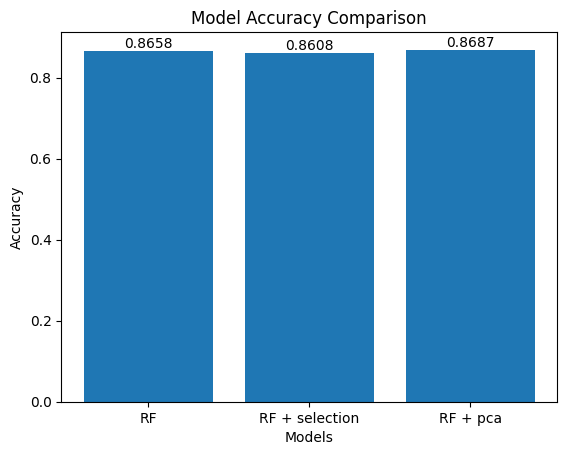

In [19]:
labels = ['RF', 'RF + selection' , 'RF + pca']
values = [acc0, acc,acc2]

plt.bar(labels, values)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Models")

# إضافة القيم فوق الأعمدة
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 4)), ha='center', va='bottom')

plt.show()

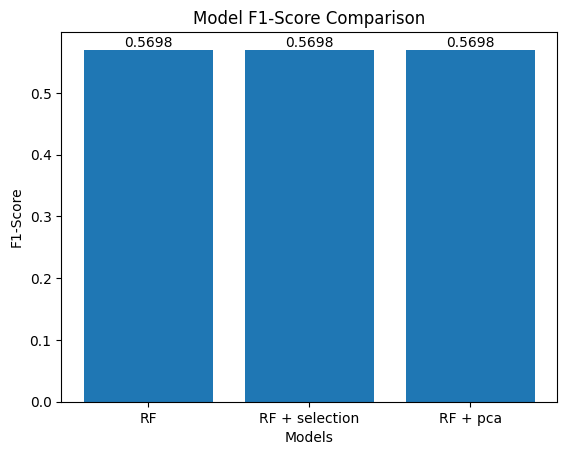

In [20]:
f1_ra = f1_score(y_test, y_pred)
f1_ra_se = f1_score(y_test , y_pred)
f1_ra_pca = f1_score(y_test, y_pred)



labels = ['RF', 'RF + selection' , 'RF + pca']
values = [f1_ra,f1_ra_se,f1_ra_pca]

plt.bar(labels, values)
plt.title("Model F1-Score Comparison")
plt.ylabel("F1-Score")
plt.xlabel("Models")

# إضافة القيم فوق الأعمدة
for i, v in enumerate(values):
    plt.text(i, v, str(round(v, 4)), ha='center', va='bottom')

plt.show()

In [17]:
##عمل Gridsearch 
grid = {'n_estimators':[50 ,150 ,200] , 
        'max_depth':[5 ,10 ,15]}
grid =GridSearchCV (
estimator =RandomForestClassifier() ,param_grid =grid ,cv=5 ,scoring='accuracy')
grid.fit(X_train ,y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'max_depth': [5, 10, ...], 'n_estimators': [50, 150, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'accuracy'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >

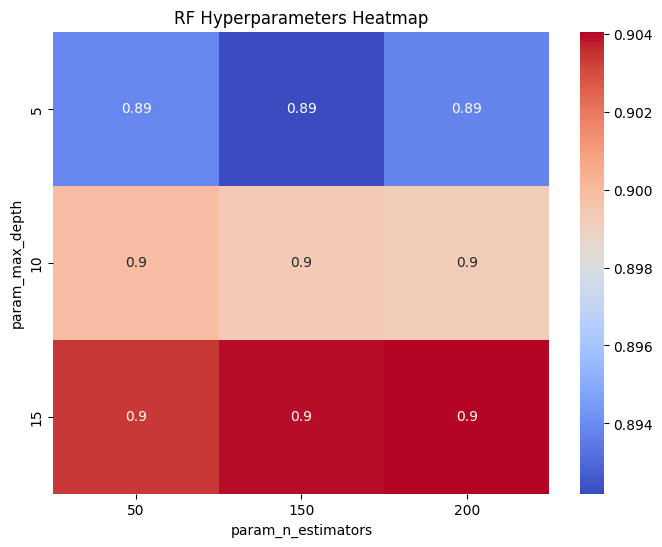

In [27]:
results =pd.DataFrame(grid.cv_results_)
pivot = results.pivot_table (values ='mean_test_score' ,index ='param_max_depth' , columns ='param_n_estimators')
plt.figure(figsize=(8,6))
sns.heatmap(pivot , annot=True , cmap='coolwarm')
plt.title('RF Hyperparameters Heatmap')
plt.show()